# **5. Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster. (Part 3, 4:19 - 40:40)**

In [82]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [83]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [84]:
len(words)

32033

In [85]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [86]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [87]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *(5/3) / (n_embd * block_size**0.5) #* 0.1
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0.01

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


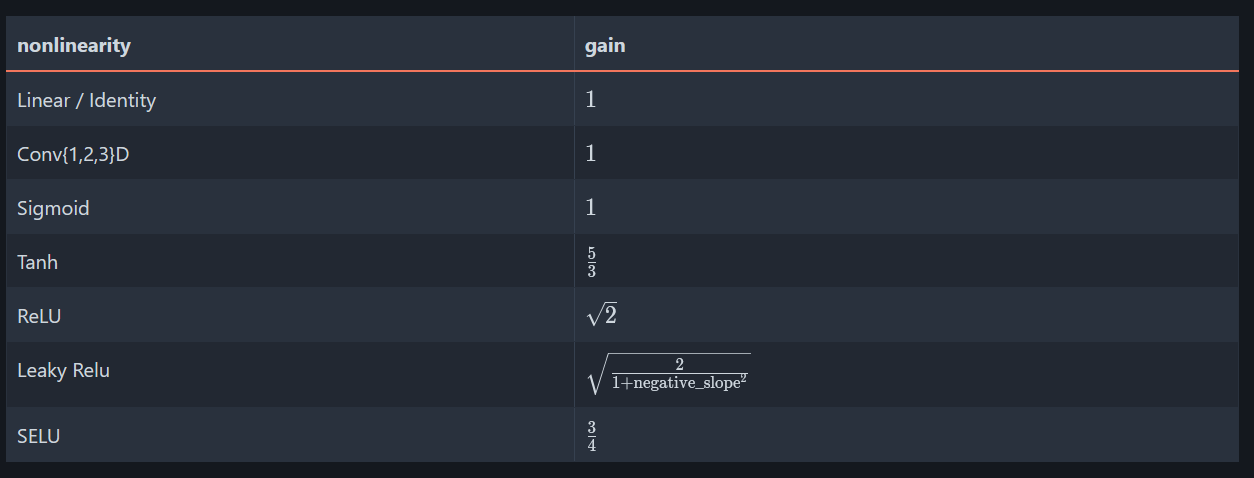

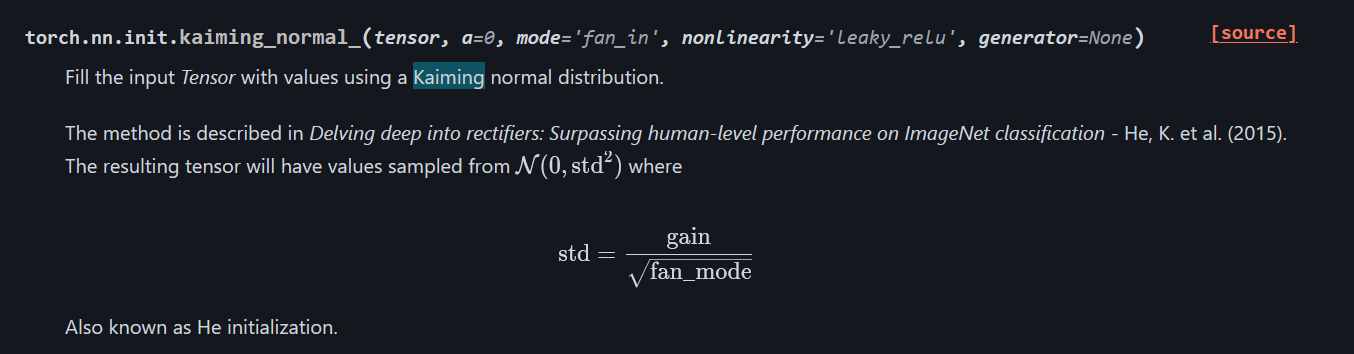

In [88]:
#bizim w1'in fan-ini = n_embd * block_size

n_embd * block_size

30

In [89]:
#şimdi yukarıdaki formülü uygulayalım. tanh'ın gaini = 5/3

(5/3) / (30**0.5)

0.3042903097250923

tensor(-0.0057) tensor(0.9890)
tensor(0.0013) tensor(3.1104)


(array([7.22895899e-06, 4.33737539e-05, 2.16868770e-05, 5.78316719e-05,
        5.06027129e-05, 1.37350221e-04, 2.31326688e-04, 4.40966498e-04,
        7.30124858e-04, 9.46993627e-04, 1.87230038e-03, 2.58073836e-03,
        4.33014643e-03, 6.79522145e-03, 1.02217480e-02, 1.54193695e-02,
        2.26844733e-02, 3.16266956e-02, 4.44508688e-02, 6.15907306e-02,
        7.99956602e-02, 9.87042060e-02, 1.19285052e-01, 1.33894778e-01,
        1.41998441e-01, 1.35398402e-01, 1.24280263e-01, 1.05080148e-01,
        8.41161668e-02, 6.50317151e-02, 4.81882406e-02, 3.44893633e-02,
        2.39784570e-02, 1.61711813e-02, 1.11759706e-02, 7.09883773e-03,
        4.61207583e-03, 2.96387318e-03, 2.02410852e-03, 1.16386240e-03,
        7.80727571e-04, 4.69882334e-04, 2.45784606e-04, 1.73495016e-04,
        1.15663344e-04, 5.06027129e-05, 2.16868770e-05, 2.16868770e-05,
        7.22895899e-06, 1.44579180e-05]),
 array([-17.01741028, -16.32574776, -15.63408524, -14.94242271,
        -14.25076019, -13.5590

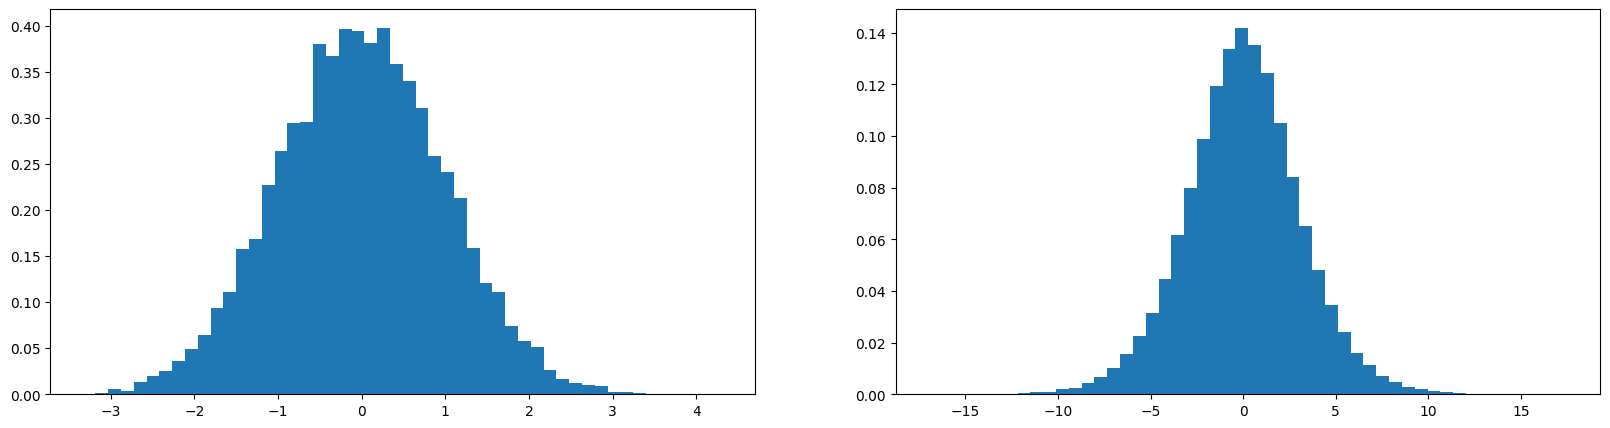

In [90]:
x = torch.randn(1000, 10)  #fan-in = 10, 10 boyutlu girdi.
w = torch.randn(10, 200) # / (10**0.5)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True)

Burada bizim tüm inputlarımız birbirinden bağımsız değişkenler olduğu için, bizim çıktıların standart sapması tam olarak sqrt(fan-in) kadar büyüyor. sqrt(10) = 3.16

In [91]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.3060
  10000/ 200000: 2.1919
  20000/ 200000: 2.2596
  30000/ 200000: 2.4189
  40000/ 200000: 1.9130
  50000/ 200000: 2.4626
  60000/ 200000: 2.3155
  70000/ 200000: 2.0855
  80000/ 200000: 2.2496
  90000/ 200000: 2.1701
 100000/ 200000: 1.8923
 110000/ 200000: 2.2005
 120000/ 200000: 1.9222
 130000/ 200000: 2.3725
 140000/ 200000: 2.3060
 150000/ 200000: 2.1967
 160000/ 200000: 1.8293
 170000/ 200000: 1.8053
 180000/ 200000: 1.8927
 190000/ 200000: 1.8422


initialization loss garipliğini çözmek için neler yapabiliriz ? initialization da zaten bir sonraki karakterin gelmesi uniform distribution'a benzer. yani her karakterin 1/27 kadar şansı vardır. fakat neural net ilk initiliaze edildiğinde logitler birbirinden çok farklı değerler olarak görülüyor. bunu çözüp, hepsini 0 a yakın şekilde başlatırsak initiliaze loss garipligini çözmüş oluruz. W2 ve b2 yi 0'a ne kadar yaklaştırırsak initiliaze loss, o kadar düşer. Fakat bu sefer de bizim aşağıdaki plotumuz buz hokeyi sopasına benzer olmaz.

ne kadar initiliaze loss u düşürmüş olsak da neural net'de daha büyük bir problem var.

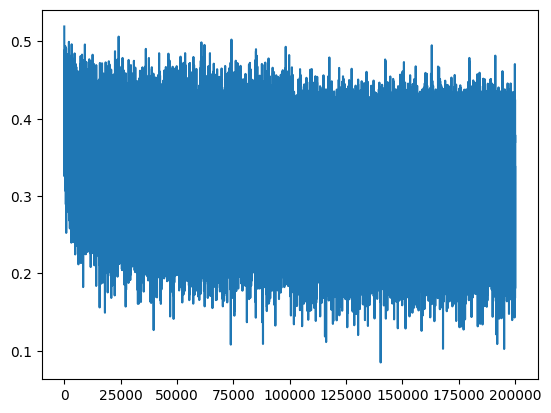

In [92]:
plt.plot(lossi)

tanh'in doygunluğa ulaşmış olması :     

tanh'ın yerel türevi 1 - h²'dir. Zincir kuralında geriye doğru gelen gradyan bu yerel türevle çarpılır:
  (1 - h**2) * out.grad. Eğer nöron çıktısı +1 veya -1'e yaklaşırsa, 1 - h² ≈ 0 olur. Bu durumda üst katmandan gelen
  hata sinyali ne kadar güçlü olursa olsun yerel türev tarafından yutulur (gradient squashing/vanishing) ve W₁ ile
  embedding'lere gradyan akışı kesilir.

In [93]:
h

tensor([[ 0.9927,  0.0879, -0.9994,  ..., -0.9976, -0.0431, -0.9237],
        [-0.7988, -0.0497, -0.8232,  ..., -0.9973, -0.1473, -0.4479],
        [-0.9658,  0.2844, -0.9412,  ...,  0.9548, -0.9172,  0.9803],
        ...,
        [ 0.2519,  0.0513, -0.6611,  ..., -0.6593, -0.9470, -0.8116],
        [ 0.9935, -0.1914,  0.9991,  ..., -0.9981,  0.7496,  0.9299],
        [-0.8202,  0.1284, -1.0000,  ...,  0.8495,  0.7453,  0.6370]],
       grad_fn=<TanhBackward0>)

In [94]:
h.shape

torch.Size([32, 200])

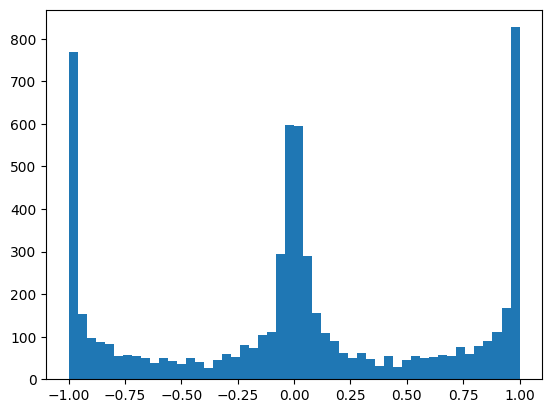

In [95]:
plt.hist(h.view(-1).tolist(), 50);

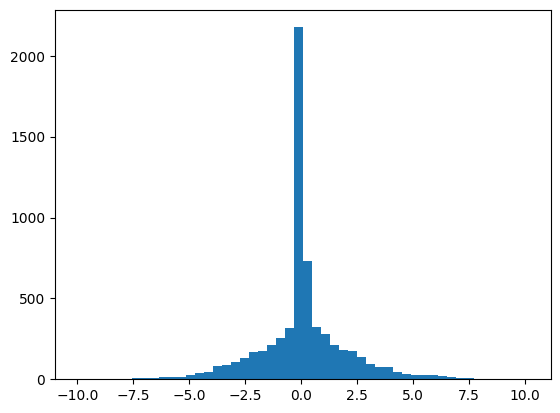

In [96]:
plt.hist(hpreact.view(-1).tolist(), 50);

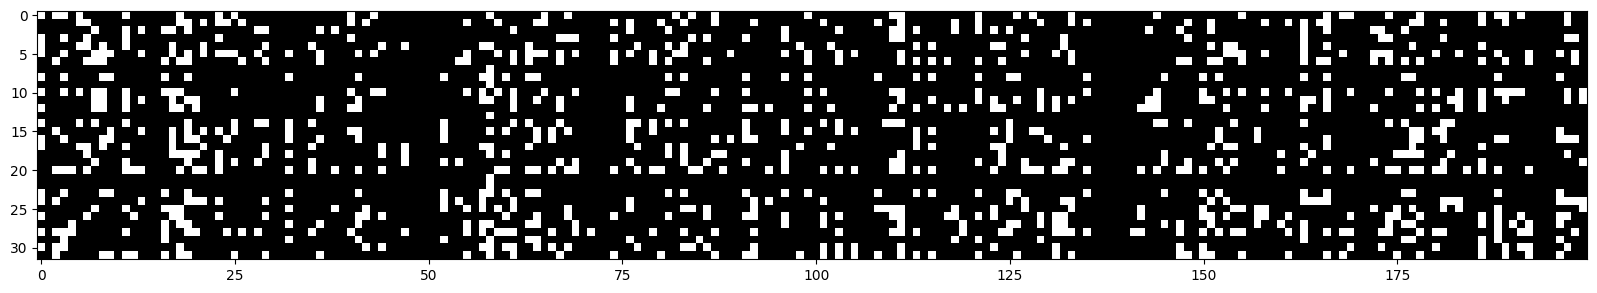

In [97]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# Burada sütunlar nöronları temsil ediyor. Eğer bir sütun baştan aşağı beyazsa, o nöron tüm eğitim batch'i için
# doymuştur. Yani yerel türevi her örnek için 0'dır; hiçbir güncelleme alamaz ve eğitim boyunca 'Dead Neuron' (ölü
# nöron) olarak kalır.

Şuan sadece bir layer icin biz bu optimizasyonu yapabildik. ama 50 layerlı bir neural nette bu initiliaze loss veya saturation of tanh problemlerini nasıl çözeceğiz ?

In [98]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.06160044670105
val 2.116924524307251


loss log
original:

train 2.1245384216308594 val 2.168196439743042
fix softmax confidently wrong:

train 2.07 val 2.13
fix tanh layer too saturated at init:

train 2.0355966091156006 val 2.1026785373687744
use semi-principled "kaiming init" instead of hacky init:

train 2.0376641750335693 val 2.106989622116089
add batch norm layer

# train 2.0668270587921143 val 2.104844808578491